# Mental Health Prediction using Machine Learning (Upgraded Project)
This notebook includes multiple models, comparison, feature importance, and tuning.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [17]:
df = pd.read_csv('social_media_mental_health_dataset.csv')
df.head()

,ScreenTime,EngagementFreq,AppearanceExposure,RecommendationClicks,AnxietyScore
0,4.25,43,1,19,6.86
1,3.29,34,4,16,7.24
2,4.47,41,2,22,8.96
3,5.78,59,5,35,10.00
4,3.15,32,1,15,4.81


In [18]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ScreenTime            150 non-null    float64
 1   EngagementFreq        150 non-null    int64  
 2   AppearanceExposure    150 non-null    int64  
 3   RecommendationClicks  150 non-null    int64  
 4   AnxietyScore          150 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 6.0 KB


,0
ScreenTime,0
EngagementFreq,0
AppearanceExposure,0
RecommendationClicks,0
AnxietyScore,0


In [19]:
df = df.dropna()

In [20]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

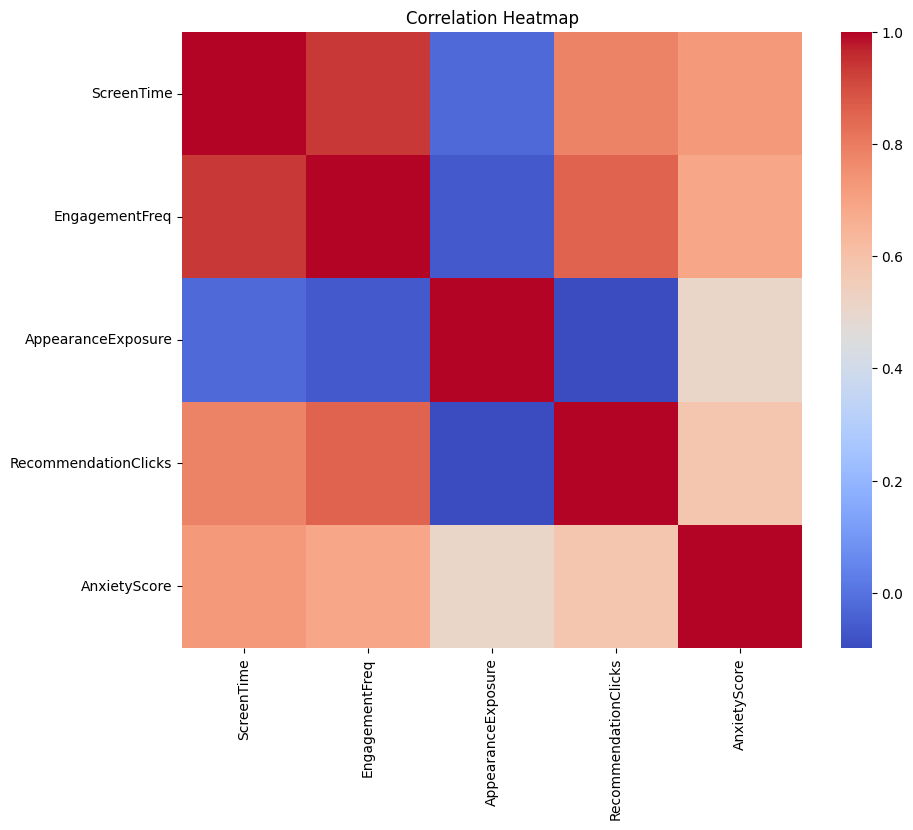

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [22]:
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]

print("Target column:", target)

Target column: AnxietyScore


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append([name, r2, mae, mse])

    print(f"\n{name}")
    print("R2:", r2)
    print("MAE:", mae)
    print("MSE:", mse)

results_df = pd.DataFrame(results, columns=['Model', 'R2 Score', 'MAE', 'MSE'])
results_df


Linear Regression
R2: 0.8227628483756283
MAE: 0.8439173768871165
MSE: 1.0014826410940334

Decision Tree
R2: 0.7936067238139146
MAE: 0.839
MSE: 1.16623

Random Forest
R2: 0.8128026832087472
MAE: 0.8366566666666652
MSE: 1.0577627856666643


,Model,R2 Score,MAE,MSE
0,Linear Regression,0.822763,0.843917,1.001483
1,Decision Tree,0.793607,0.839000,1.166230
2,Random Forest,0.812803,0.836657,1.057763


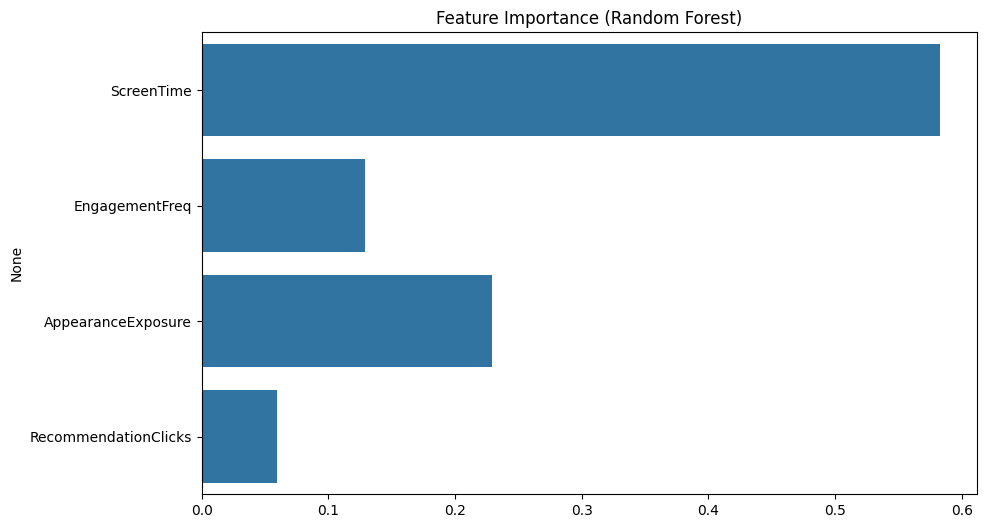

In [26]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance (Random Forest)')
plt.show()

In [27]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'n_estimators': 100}


In [28]:
cv_scores = cross_val_score(RandomForestRegressor(), X, y, cv=5)
print("CV Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

CV Scores: [0.81459486 0.60566782 0.72066318 0.86083635 0.82733653]
Average CV Score: 0.7658197486586822


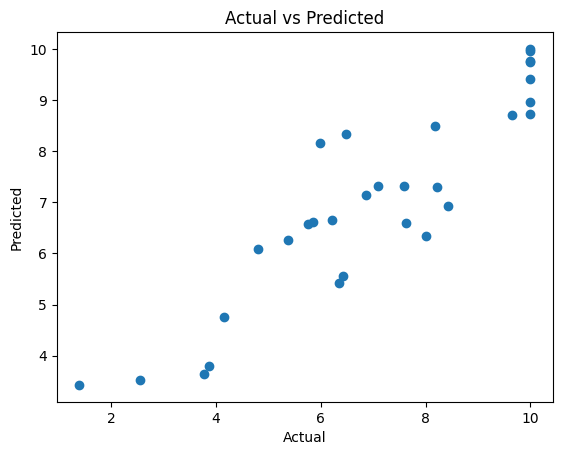

In [29]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

## Conclusion
Random Forest performed best due to ensemble learning and reduced overfitting.
Feature importance helps understand key factors affecting mental health.

In [15]:
y_pred_tuned = best_model.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

print(f"\nBest Tuned Random Forest Model Performance:")
print(f"R2 Score: {r2_tuned:.4f}")
print(f"MAE: {mae_tuned:.4f}")
print(f"MSE: {mse_tuned:.4f}")

# Optionally, add this to the results_df for a complete comparison
results_df_tuned = results_df.copy()
results_df_tuned.loc[len(results_df_tuned)] = ['Random Forest (Tuned)', r2_tuned, mae_tuned, mse_tuned]

print("\nUpdated Model Comparison:")
print(results_df_tuned)


Best Tuned Random Forest Model Performance:
R2 Score: 0.8229
MAE: 0.8044
MSE: 1.0009

Updated Model Comparison:
                   Model  R2 Score       MAE       MSE
0      Linear Regression  0.822763  0.843917  1.001483
1          Decision Tree  0.769667  0.890000  1.301500
2          Random Forest  0.819577  0.794690  1.019484
3  Random Forest (Tuned)  0.822869  0.804447  1.000881
